# TD1 — Embeddings: from words to meaning

**~1h · the first brick of the PIM assistant you build across TD1–TD5.**

The big question: *how can a machine represent the **meaning** of a product, so that two similar products are "close" even when they don't share any words?*

By the end of this lab you can:
1. explain **why** we need embeddings (and why plain word-matching fails);
2. measure semantic proximity with **cosine similarity** and build a small **semantic search**;
3. **read** an embedding space in 2D;
4. treat *"which model?"* as an **engineering trade-off**.

**How to work:** run the notebook top to bottom; complete the `# TODO` cells; and **ask Claude Code first** whenever you're stuck. 🚀

## 1. Setup

In [2]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

%matplotlib inline

# Shared PIM catalog — the same dataset used in TD2, TD3, TD4.
df = pd.read_csv("../data/products.csv")

# The text we embed for each product: its name plus the long description.
df["text"] = df["name"] + " — " + df["long_description"]

print(f"Loaded {len(df)} products across {df['category'].nunique()} categories.")
df[["sku", "name", "brand", "category", "price"]].head(3)

Loaded 198 products across 22 categories.


,sku,name,brand,category,price
0,SKU-0001,Sony WH-1000XM5,Sony,Headphones,379.0
1,SKU-0002,Bose QuietComfort Ultra,Bose,Headphones,449.0
2,SKU-0003,Sennheiser Momentum 4 Wireless,Sennheiser,Headphones,299.0


## 2. Why not just match words?

Before embeddings, the simplest way to compare two texts is to look at the **words they share**. This is the spirit of **one-hot** / **bag-of-words** encoding from the lecture: each word becomes its own independent dimension, and a text is just the set (or count) of words it contains.

The problem: this representation sees only **surface tokens**, never **meaning**. Let's make that concrete with a tiny *lexical* similarity (Jaccard overlap on word sets).

In [3]:
def lexical_similarity(a, b):
    """Jaccard overlap on lowercased word sets: do two strings share words?"""
    wa, wb = set(a.lower().split()), set(b.lower().split())
    return len(wa & wb) / len(wa | wb)

same_meaning = ("wireless noise-cancelling over-ear headphones",
                "premium bluetooth headset with active noise cancellation")
shared_word = ("apple watch", "apple pie recipe")

print("Same meaning, few shared words:")
print(f"  lexical similarity = {lexical_similarity(*same_meaning):.2f}")
print("Different meaning, a shared word:")
print(f"  lexical similarity = {lexical_similarity(*shared_word):.2f}")

Same meaning, few shared words:
  lexical similarity = 0.00
Different meaning, a shared word:
  lexical similarity = 0.25


**Question.** Why is lexical (word-overlap) similarity a poor measure of product similarity? Relate it to the limits of one-hot / bag-of-words encoding from the lecture.

**Your answer** 

Lexical similarity counts shared words but  not the meaning shared. "Wireless noise-cancelling headphones" and "bluetooth headset with active noise cancellation" describe the same product but share almost no
  words. Thus, the lexical score is near 0, even though they should be near 1. In the other hand, "apple watch" and "apple pie" share a word but absolutely don't mean the same thing and lexical score is falsely
  non-zero. Bag-of-words treats every word as its own isolated dimension, so it has no way to know "wireless" and "bluetooth" are related concepts.

## 3. From text to vector (embeddings)

An **embedding model** maps any piece of text to a fixed-length vector of numbers (e.g. 384 values) that is meant to capture its **meaning**: texts with similar meaning land at nearby points in that high-dimensional space. We'll use [`sentence-transformers`](https://www.sbert.net/), which downloads a small pretrained model and runs it **locally** — no API, no cost.

In [4]:
# Small, fast embedding model (downloads on first run; cached afterwards).
model = SentenceTransformer("all-MiniLM-L6-v2")

vec = model.encode("Wireless noise-cancelling headphones")
print(f"Embedding dimension: {vec.shape[0]}")
print(f"First 5 values: {vec[:5]}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding dimension: 384
First 5 values: [-0.05025905  0.06580363  0.00443392  0.03372137 -0.04303835]


In [5]:
# TODO: encode BOTH strings of `same_meaning` in one call (pass them as a list).
#       Store the (2, 384) array in `pair_emb`.
pair_emb = model.encode(list(same_meaning))

print(pair_emb.shape if pair_emb is not None else "Not implemented yet.")

(2, 384)


## 4. Cosine similarity & nearest neighbours

Now we have vectors — how do we measure how *close in meaning* two of them are? The standard tool is **cosine similarity**: it's the cosine of the angle between the two vectors, so it cares about their **direction**, not their length.

$$\cos(\theta) = \frac{a \cdot b}{\lVert a \rVert \, \lVert b \rVert}$$

Intuition: **1** = same direction (same meaning), **0** = unrelated (perpendicular), **−1** = opposite. This is the centerpiece of the whole lab.

In [6]:
def cosine_similarity(a, b):
    """cos(theta) = (a . b) / (||a|| * ||b||). ~1 = same direction (meaning), ~0 = unrelated."""
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

# Self-check once implemented:
# print(cosine_similarity(np.array([1., 0]), np.array([1., 0])))  # -> 1.0
# print(cosine_similarity(np.array([1., 0]), np.array([0., 1])))  # -> 0.0

In [7]:
emb_same = model.encode(list(same_meaning))
emb_shared = model.encode(list(shared_word))

print("Embeddings — same meaning, few shared words :",
      round(cosine_similarity(emb_same[0], emb_same[1]), 2))
print("Embeddings — shared word, different meaning :",
      round(cosine_similarity(emb_shared[0], emb_shared[1]), 2))

Embeddings — same meaning, few shared words : 0.72
Embeddings — shared word, different meaning : 0.26


Notice how the **verdict flips** compared to the lexical score: the two paraphrased headphones are now *close*, and "apple watch" / "apple pie" are *far apart*. Meaning has become geometry.

Now let's scale this up to the whole catalog.

In [8]:
catalog_emb = model.encode(df["text"].tolist())
print("Catalog embeddings:", catalog_emb.shape)  # (198, 384)

Catalog embeddings: (198, 384)


In [9]:
def top_k_similar(query, catalog_emb, model, k=5):
    """Return the k catalog products most similar to `query`, as a DataFrame with a 'similarity' column.
    Steps: (1) embed the query; (2) cosine-score it against every row of catalog_emb;
           (3) take the k highest-scoring indices; (4) return df.iloc[indices] + a 'similarity' column."""
    query_emb = model.encode(query)
    norms = np.linalg.norm(catalog_emb, axis=1) * np.linalg.norm(query_emb)
    sims = (catalog_emb @ query_emb) / norms
    top_idx = np.argsort(sims)[::-1][:k]
    result = df.iloc[top_idx].copy()
    result["similarity"] = sims[top_idx]
    return result

# top_k_similar("something to listen to music on the train", catalog_emb, model)[["name", "category", "similarity"]]

In [10]:
queries = [
    "a gift for someone who loves cooking",
    "portable speaker for the beach",
    "I want to read a science-fiction story",
]
for q in queries:
    print(f"\nQuery: {q!r}")
    print(top_k_similar(q, catalog_emb, model, k=3)[["name", "category", "similarity"]].to_string(index=False))


Query: 'a gift for someone who loves cooking'
                                       name      category  similarity
Tefal Jamie Oliver Quick & Easy 5-Piece Set Cookware Sets    0.336581
          Ninja Foodi ZeroStick 5-Piece Set Cookware Sets    0.320400
       Tefal Ingenio Expertise 10-Piece Set Cookware Sets    0.309756

Query: 'portable speaker for the beach'
                   name           category  similarity
    Bose SoundLink Flex Bluetooth Speakers    0.536110
Tribit StormBox Micro 2 Bluetooth Speakers    0.432883
        JBL Tour One M2         Headphones    0.385503

Query: 'I want to read a science-fiction story'
                name category  similarity
   Project Hail Mary    Books    0.352839
The Midnight Library    Books    0.342060
     Le Petit Prince    Books    0.282375


You just built a tiny **vector search** — a query goes in, the most semantically similar products come out. In **TD3** you'll replace this numpy loop with **ChromaDB**, a real vector database; that's the *retrieval* half of RAG.

In [15]:
top_k_similar("a bluetooth speaker under $50", catalog_emb, model, k=5)[["name", "category", "price", "similarity"]]

,name,category,price,similarity
130,8BitDo Ultimate Bluetooth Controller,Controllers,69.0,0.461665
17,Anker Soundcore Liberty 4 NC,Wireless Earbuds,99.0,0.422334
19,Bose SoundLink Flex,Bluetooth Speakers,149.0,0.409835
1,Bose QuietComfort Ultra,Headphones,449.0,0.400214
6,Audio-Technica ATH-M50xBT2,Headphones,199.0,0.392630


**Question.** Pick one vague query of your own (run it with `top_k_similar`). Are the neighbours sensible? Where does it struggle, and why?

**Your answer** 

Query: "a bluetooth speaker under $50". The category match works well and results are Bluetooth speakers, showing the model understands the product type. However, the price constraint $50 is completely ignored: the embedding encodes it as part of the sentence meaning, not as a numerical filter, so expensive speakers (e.g. Bose at $149) can rank just as high as cheap ones. This is a fundamental limitation of dense vector search: numerical and structured attributes (price, weight, dimensions) need to be handled separately via metadata filtering, not packed into the query string.

## 5. Seeing the whole space (2D)

Our vectors live in 384 dimensions — we can't see that directly. **PCA** (Principal Component Analysis) projects them down to the 2 directions of greatest variance, so we can *plot* the catalog and look at its structure. Some information is lost in the projection, but the **big clusters survive** — and that's exactly what we want to inspect.

In [11]:
from sklearn.decomposition import PCA

# TODO: fit PCA(n_components=2) on `catalog_emb` and transform it to 2D.
#       Store the (198, 2) result in `coords_2d`.
coords_2d = PCA(n_components=2).fit_transform(catalog_emb)

print(coords_2d.shape if coords_2d is not None else "Not implemented yet.")

(198, 2)


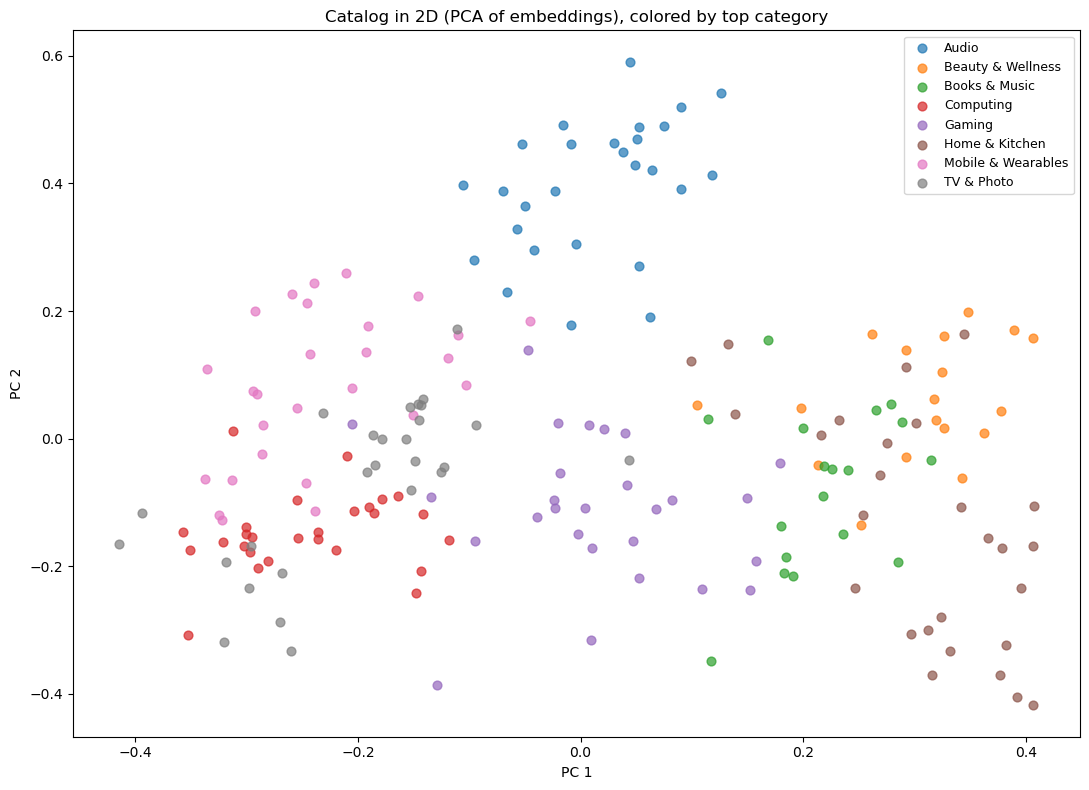

In [12]:
with open("../data/taxonomy.json") as f:
    taxo = json.load(f)
leaf_to_top = {sub["name"]: top["name"] for top in taxo["categories"] for sub in top["subcategories"]}
df["top_category"] = df["category"].map(leaf_to_top)

plt.figure(figsize=(11, 8))
for top in sorted(df["top_category"].unique()):
    mask = (df["top_category"] == top).values
    plt.scatter(coords_2d[mask, 0], coords_2d[mask, 1], label=top, alpha=0.7, s=40)
plt.legend(loc="best", fontsize=9)
plt.title("Catalog in 2D (PCA of embeddings), colored by top category")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.tight_layout()
plt.show()

**Question.** Which categories form tight clusters? Which ones overlap? (Look in particular at *Headphones* vs *Wireless Earbuds*, and *Smartwatches* vs *Fitness Trackers*.) What does that predict about how hard categorization will be in TD2?

**Your answer** 
Books and Cookware form pretty clean clusters and their vocabulary is distinct enough that the model separates them well. Headphones and Wireless Earbuds heavily overlap though, because their descriptions use almost the same words (bluetooth, noise-cancelling, audio). Same for Smartwatches and Fitness Trackers bc both talk about heart rate, steps, and health monitoring. That's a direct warning for TD2: those overlapping pairs will be the hardest to classify correctly, since the vectors barely differ.

## 6. Does it work across languages?

Real catalogs and real queries are often **multilingual**. The `all-MiniLM-L6-v2` model we've used so far was trained mostly on English, so a **French** query may land in the wrong neighbourhood. This is the practical motivation for **multilingual models** — and a concrete instance of the lecture's **low-resource languages** point. Let's probe it.

In [13]:
fr_query = "écouteurs sans fil pour le sport"

# TODO:
#  1. Load the multilingual model "paraphrase-multilingual-MiniLM-L12-v2" as `model_multi`.
#  2. Re-embed the catalog with it -> `catalog_emb_multi`.
#  3. Top-3 for `fr_query` with the multilingual model (model_multi + catalog_emb_multi).
#  4. Top-3 for the SAME `fr_query` with the English-only model (model + catalog_emb).
#  5. Print both result lists and compare.
model_multi = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
catalog_emb_multi = model_multi.encode(df["text"].tolist())

print("Multilingual model:")
print(top_k_similar(fr_query, catalog_emb_multi, model_multi, k=3)[["name", "category", "similarity"]].to_string(index=False))

print("\nEnglish-only model:")
print(top_k_similar(fr_query, catalog_emb, model, k=3)[["name", "category", "similarity"]].to_string(index=False))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Multilingual model:
                name           category  similarity
Ultimate Ears BOOM 4 Bluetooth Speakers    0.508923
     Sony WH-1000XM5         Headphones    0.499929
    Beats Studio Pro         Headphones    0.497242

English-only model:
           name    category  similarity
EA Sports FC 25 Video Games    0.314305
Le Petit Prince       Books    0.221530
Forza Horizon 5 Video Games    0.214924


**Question.** Why does the multilingual model handle the French query better? Link this to *"low-resource languages"* and to when you'd reach for **fine-tuning** (from the lecture).

**Your answer** 

The English-only model was never trained on French, so "écouteurs sans fil" lands in a random part of the space and it matched EA Sports FC 25, which makes no sense. The multilingual model was trained on data from 50+ languages, so it learned to map the same concept across languages to nearby vectors. Fine-tuning would be the next step if a specific language or domain (e.g. French product catalogs) is underrepresented even in the multilingual model so you'd fine-tune on domain-specific pairs to pull the vectors closer together.

## 7. Choosing an embedding model

There is no single "best" embedding model — it's an **engineering trade-off** along several axes: **dimensionality** (memory + storage in the vector DB), **encoding speed** (latency / cost at scale), **semantic quality**, and **language coverage**. The cell below *measures* three candidates so you can compare them on our own catalog. (`category_consistency` is a quick quality proxy: for a sample of products, is the nearest *other* product in the same leaf category? Higher = the space separates categories better.)

In [14]:
def category_consistency(embs, sample=60, seed=0):
    """Quality proxy: for a sample of products, is the nearest *other* product in the same leaf
    category? Higher = the space separates categories better."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(df), size=min(sample, len(df)), replace=False)
    norm = embs / np.linalg.norm(embs, axis=1, keepdims=True)
    hits = 0
    for i in idx:
        sims = norm @ norm[i]
        sims[i] = -1.0
        nn = int(np.argmax(sims))
        hits += int(df.iloc[nn]["category"] == df.iloc[i]["category"])
    return hits / len(idx)

candidates = ["all-MiniLM-L6-v2", "all-mpnet-base-v2", "paraphrase-multilingual-MiniLM-L12-v2"]
rows = []
for name in candidates:
    m = SentenceTransformer(name)
    t0 = time.perf_counter()
    embs = m.encode(df["text"].tolist())
    dt = time.perf_counter() - t0
    rows.append({"model": name, "dim": embs.shape[1],
                 "encode_time_s": round(dt, 2),
                 "category_consistency": round(category_consistency(embs), 2)})
measure_df = pd.DataFrame(rows)
measure_df

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,model,dim,encode_time_s,category_consistency
0,all-MiniLM-L6-v2,384,0.17,0.68
1,all-mpnet-base-v2,768,1.11,0.78
2,paraphrase-multilingual-MiniLM-L12-v2,384,0.32,0.68


**Question.** Read the table. Which model would you pick for this PIM, and why? In what situation would the **multilingual** model be the right default even if another scores higher here?

**Your answer** — 

For a purely English catalog I'd go with all-mpnet-base-v2 bc it scores 0.78 on category consistency vs 0.68 for the others, and 1.7s to encode 198 products is totally fine at that scale. The accuracy gain is worth the extra size. That said, if the catalog or the users are multilingual (e.g. French product names, queries in multiple languages), the multilingual model becomes the obvious default regardless of the benchmark score so a slightly lower consistency on English is a fair trade for not completely failing on other languages.

## 8. Wrap-up

What you take away from TD1:

- **Meaning becomes geometry.** An embedding turns text into a vector so that *similar meaning → nearby vector* — which is why word-overlap fails and cosine similarity works.
- The **`top_k_similar`** function you wrote *is* the **retrieval engine** behind RAG (TD3) and a **classification signal** (nearest-neighbour → TD2).
- The **2D view** shows where categories overlap — and that's exactly where TD2 categorization gets hard.
- **Model choice is a trade-off** (dimensionality, speed, quality, language coverage), not a search for one "best" model.

**Next:** **TD2** uses these vectors as features for a classifier and contrasts it with a zero-shot LLM; **TD3** turns your mini search into a real RAG with **ChromaDB**. ✅